# ⚖️ Comparing Means — The Parametric Toolkit
### Stage 3: t-test, ANOVA & Tukey HSD  |  ⏱️ ~40-minute session

---

**Recap from Stage 2:** you now know how to check normality (Shapiro-Wilk) and equal variance (Levene's). This session is where that groundwork pays off — every test below is a **parametric** test, meaning it trusts that your data is roughly normal.

### The big question all of these answer:
> *"Is the difference between these group averages real, or just random noise?"*

### Session map 

| Topic |
|---|
| One-sample t-test |
| Independent samples t-test |
| Paired samples t-test |
| One-way ANOVA |
| Tukey HSD post-hoc |
| Two-way ANOVA (bonus, if time allows) |

We'll use `tips` (restaurant bills) for the t-tests, `penguins` for ANOVA, and one small synthetic paired dataset (before/after weights) since paired data needs two measurements per *same* subject — something `tips` doesn't naturally have.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

plt.rcParams['figure.figsize'] = (7, 4)
sns.set_style("whitegrid")

tips = sns.load_dataset("tips")
penguins = sns.load_dataset("penguins").dropna()

print(tips.shape, penguins.shape)
tips.head()


(244, 7) (333, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 1️⃣ One-Sample t-test — "Does my sample match a known/claimed value?"

### Theory

Used when you have **one group** and want to compare its mean against a **fixed, known number** (a benchmark, target, or historical value).

$$t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}$$

- **H₀:** The sample mean equals the claimed value (μ = μ₀)
- **H₁:** The sample mean is different from μ₀

**Assumptions:** data is roughly normal (Shapiro-Wilk from Stage 2), observations are independent.

### Scenario
The restaurant manager claims: *"On average, customers pay $20 per bill."* Let's test that claim against our actual `total_bill` data.


In [2]:
claimed_mean = 20.0

t_stat, p_value = stats.ttest_1samp(tips['total_bill'], popmean=claimed_mean)
print(f"Sample mean: {tips['total_bill'].mean():.2f}")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("Verdict: Reject H0 -> True average bill is significantly different from $20")
else:
    print("Verdict: Fail to reject H0 -> No evidence average bill differs from $20")


Sample mean: 19.79
t-statistic: -0.3756
p-value: 0.707547
Verdict: Fail to reject H0 -> No evidence average bill differs from $20


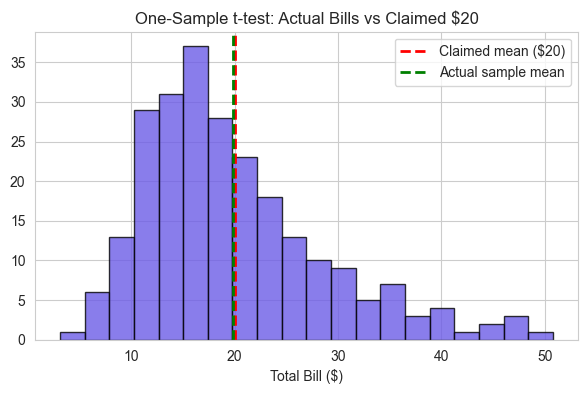

In [3]:
fig, ax = plt.subplots()
ax.hist(tips['total_bill'], bins=20, color='#6c5ce7', edgecolor='black', alpha=0.8)
ax.axvline(claimed_mean, color='red', linestyle='--', linewidth=2, label='Claimed mean ($20)')
ax.axvline(tips['total_bill'].mean(), color='green', linestyle='--', linewidth=2, label='Actual sample mean')
ax.set_title("One-Sample t-test: Actual Bills vs Claimed $20")
ax.set_xlabel("Total Bill ($)")
ax.legend()
plt.show()


## 2️⃣ Independent Samples t-test — "Do two separate groups differ?"

### Theory

Used to compare the means of **two independent (unrelated) groups** — e.g., smokers vs non-smokers, Male vs Female.

$$t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}$$

- **H₀:** μ₁ = μ₂ (the two group means are equal)
- **H₁:** μ₁ ≠ μ₂

**This is where Stage 2 pays off:** if Levene's test said variances were equal, use the **Student's t-test** (`equal_var=True`). If variances were unequal, use **Welch's t-test** (`equal_var=False`) — it's safer by default when you're unsure.

### Scenario
Do **smokers** and **non-smokers** leave different average total bills?


In [4]:
smoker_bills = tips.loc[tips['smoker'] == 'Yes', 'total_bill']
nonsmoker_bills = tips.loc[tips['smoker'] == 'No', 'total_bill']

# Step 1: check variance equality first (Stage 2 skill!)
lev_stat, lev_p = stats.levene(smoker_bills, nonsmoker_bills)
print(f"Levene's test p-value: {lev_p:.4f}")
equal_var_flag = lev_p > 0.05
print(f"-> Using equal_var={equal_var_flag} for the t-test\n")

# Step 2: run the appropriate t-test
t_stat, p_value = stats.ttest_ind(smoker_bills, nonsmoker_bills, equal_var=equal_var_flag)
print(f"Smoker mean: {smoker_bills.mean():.2f} | Non-smoker mean: {nonsmoker_bills.mean():.2f}")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("Verdict: Reject H0 -> Smokers and non-smokers have significantly different average bills")
else:
    print("Verdict: Fail to reject H0 -> No significant difference between the two groups")


Levene's test p-value: 0.0452
-> Using equal_var=False for the t-test

Smoker mean: 20.76 | Non-smoker mean: 19.19
t-statistic: 1.2843
p-value: 0.200805
Verdict: Fail to reject H0 -> No significant difference between the two groups


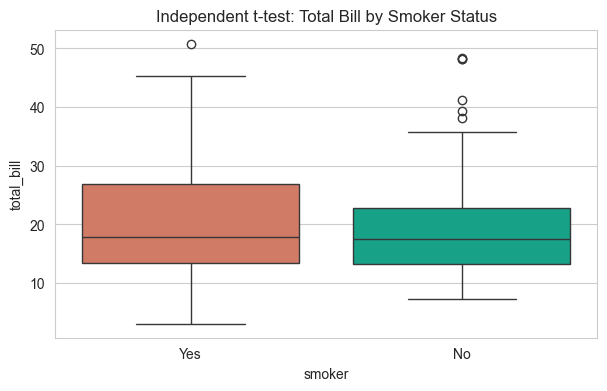

In [5]:
fig, ax = plt.subplots()
sns.boxplot(data=tips, x='smoker', y='total_bill', hue='smoker',
            palette=['#e17055', '#00b894'], ax=ax, legend=False)
ax.set_title("Independent t-test: Total Bill by Smoker Status")
plt.show()


### 🎯 30-second challenge
Run the same test comparing `tip` between **Male** and **Female** customers. Remember: check Levene's first!


In [7]:
male_tip = tips.loc[tips['sex'] == 'Male', 'tip']
female_tip = tips.loc[tips['sex'] == 'Female', 'tip']

lev_p = stats.levene(male_tip, female_tip).pvalue
t_stat, p_value = stats.ttest_ind(male_tip, female_tip, equal_var=(lev_p > 0.05))
print(f"Levene p={lev_p:.4f} | t={t_stat:.4f}, p={p_value:.6f}")

if p_value < 0.05:
    print("Verdict: Reject H0 -> Smokers and non-smokers have significantly different average bills")
else:
    print("Verdict: Fail to reject H0 -> No significant difference between the two groups")


Levene p=0.1595 | t=1.3879, p=0.166456
Verdict: Fail to reject H0 -> No significant difference between the two groups


## 3️⃣ Paired Samples t-test — "Did the SAME subjects change?"

### Theory

Used when you measure the **same subjects twice** — before/after an intervention, or two related conditions. Because each subject is compared to *themselves*, this test is much more powerful at detecting real change (it cancels out individual variation).

$$t = \frac{\bar{d}}{s_d / \sqrt{n}}$$

where **d** = the difference between each pair of measurements.

- **H₀:** Mean difference (d̄) = 0 (no real change)
- **H₁:** Mean difference ≠ 0

**Key distinction from independent t-test:** independent = two *different* groups of people; paired = the *same* people/units, measured twice.

### Scenario
A gym runs a 6-week weight-loss program. Let's simulate realistic before/after weights for 20 participants and test whether the program had a real effect.


In [8]:
np.random.seed(42)
n = 20
before = np.random.normal(loc=85, scale=10, size=n)          # starting weight (kg)
change = np.random.normal(loc=-3, scale=2.5, size=n)          # average 3kg loss, with variation
after = before + change

weight_df = pd.DataFrame({'participant': range(1, n+1), 'before': before, 'after': after})
weight_df.head()


,participant,before,after
0,1,89.967142,90.631263
1,2,83.617357,80.052916
2,3,91.476885,88.645706
3,4,100.230299,93.668428
4,5,82.658466,78.297509


In [9]:
t_stat, p_value = stats.ttest_rel(weight_df['before'], weight_df['after'])
mean_diff = (weight_df['before'] - weight_df['after']).mean()

print(f"Mean weight loss: {mean_diff:.2f} kg")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("Verdict: Reject H0 -> The program caused a statistically significant change in weight")
else:
    print("Verdict: Fail to reject H0 -> No significant change detected")


Mean weight loss: 3.66 kg
t-statistic: 6.7725
p-value: 0.000002
Verdict: Reject H0 -> The program caused a statistically significant change in weight


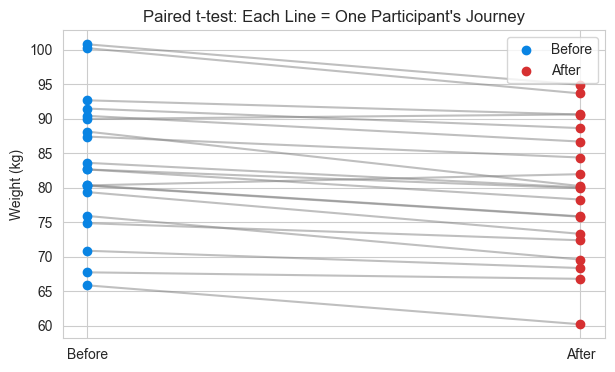

In [10]:
fig, ax = plt.subplots()
for i in range(n):
    ax.plot([0, 1], [weight_df['before'][i], weight_df['after'][i]], color='gray', alpha=0.5)
ax.scatter([0]*n, weight_df['before'], color='#0984e3', label='Before', zorder=3)
ax.scatter([1]*n, weight_df['after'], color='#d63031', label='After', zorder=3)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Before', 'After'])
ax.set_ylabel("Weight (kg)")
ax.set_title("Paired t-test: Each Line = One Participant's Journey")
ax.legend()
plt.show()


## 4️⃣ One-Way ANOVA — "Do 3+ groups differ?"

### Theory

A t-test only compares 2 groups. What if you have **3 or more**? Running multiple t-tests inflates your Type I error rate (more tests = more chances of a false positive). **ANOVA (Analysis of Variance)** solves this by testing all groups at once.

It compares **variance between groups** to **variance within groups**:

$$F = \frac{\text{Variance between groups}}{\text{Variance within groups}}$$

- **H₀:** All group means are equal (μ₁ = μ₂ = μ₃ = ...)
- **H₁:** At least one group mean is different

**Important:** ANOVA tells you groups differ overall — it does **not** tell you *which* groups differ. That's what Tukey HSD is for (next section).

### Scenario
Do **body mass** measurements differ across the 3 penguin species (Adelie, Chinstrap, Gentoo)?


In [11]:
adelie = penguins.loc[penguins['species'] == 'Adelie', 'body_mass_g']
chinstrap = penguins.loc[penguins['species'] == 'Chinstrap', 'body_mass_g']
gentoo = penguins.loc[penguins['species'] == 'Gentoo', 'body_mass_g']

f_stat, p_value = stats.f_oneway(adelie, chinstrap, gentoo)
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.6e}")

if p_value < 0.05:
    print("Verdict: Reject H0 -> At least one species has a significantly different body mass")
else:
    print("Verdict: Fail to reject H0 -> No significant difference across species")


F-statistic: 341.8949
p-value: 3.744505e-81
Verdict: Reject H0 -> At least one species has a significantly different body mass


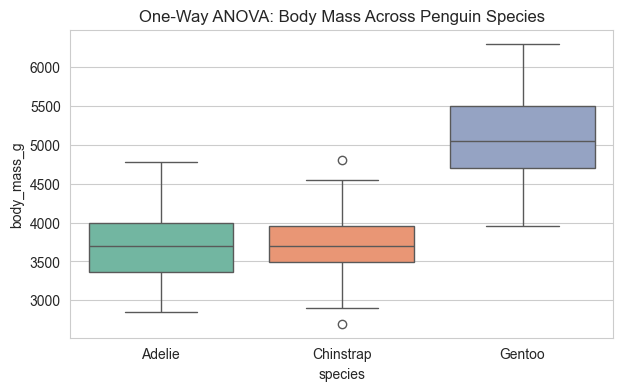

In [12]:
fig, ax = plt.subplots()
sns.boxplot(data=penguins, x='species', y='body_mass_g', hue='species',
            palette='Set2', ax=ax, legend=False)
ax.set_title("One-Way ANOVA: Body Mass Across Penguin Species")
plt.show()


## 5️⃣ (OPTIONAL)Tukey HSD — "OK, ANOVA says they differ. But WHICH pairs?"

### Theory

ANOVA gave us a single yes/no answer for all groups combined. **Tukey's Honestly Significant Difference (HSD)** test is a **post-hoc** test — run *after* a significant ANOVA — that compares every pair of groups while controlling the overall false-positive rate (unlike running many separate t-tests).

- For each pair of groups, it checks whether their mean difference is larger than what we'd expect by chance, given the number of comparisons being made.
- Output includes an adjusted p-value and a "reject" column (True = significant difference for that pair).

> ⚠️ Only run Tukey HSD **after** ANOVA shows a significant result — running it "just in case" defeats its purpose of controlled comparisons.


In [13]:
tukey_result = pairwise_tukeyhsd(endog=penguins['body_mass_g'],
                                   groups=penguins['species'],
                                   alpha=0.05)
print(tukey_result)


      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
  group1    group2   meandiff p-adj    lower     upper   reject
---------------------------------------------------------------
   Adelie Chinstrap   26.9239 0.9164 -132.3528  186.2005  False
   Adelie    Gentoo 1386.2726    0.0 1252.2897 1520.2554   True
Chinstrap    Gentoo 1359.3487    0.0 1194.4304 1524.2671   True
---------------------------------------------------------------


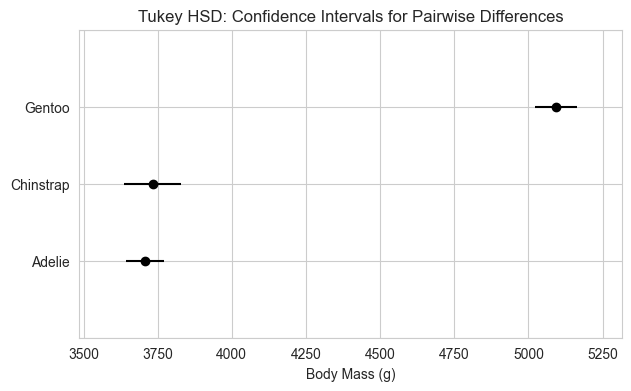

In [14]:
fig = tukey_result.plot_simultaneous(figsize=(7, 4))
plt.title("Tukey HSD: Confidence Intervals for Pairwise Differences")
plt.xlabel("Body Mass (g)")
plt.show()


**How to read this plot:** if a group's confidence interval line does **not** overlap with another group's, their means are significantly different. Here, all three species show non-overlapping intervals — confirming what Tukey's table already told us: **every pair of species differs significantly** in body mass.


## 6️⃣ (OPTIONAL)Bonus (if time allows): Two-Way ANOVA — "Do TWO factors matter, together?"

### Theory

One-way ANOVA handles one grouping factor. **Two-way ANOVA** lets you test **two factors at once** — plus their **interaction** (does the effect of one factor depend on the level of the other?).

For penguins: does **body mass** depend on `species`, on `sex`, or on a *combination* of both?

Three questions, one model:
1. Main effect of species
2. Main effect of sex
3. Interaction effect (species × sex)


In [14]:
model = ols('body_mass_g ~ C(species) + C(sex) + C(species):C(sex)', data=penguins).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table


,sum_sq,df,F,PR(>F)
C(species),1.434016e+08,2.0,749.015666,8.144406e-123
C(sex),3.709026e+07,1.0,387.459976,1.902273e-57
C(species):C(sex),1.676557e+06,2.0,8.756997,1.973489e-04
Residual,3.130263e+07,327.0,NaN,NaN


**Reading the table:** look at the `PR(>F)` column (the p-value) for each row.
- `C(species)` → does species alone matter?
- `C(sex)` → does sex alone matter?
- `C(species):C(sex)` → does the *combination* matter beyond what each explains alone?

If the interaction term is significant, it means the effect of sex on body mass isn't the same across species — e.g., the male/female gap might be bigger in Gentoos than in Adelies.


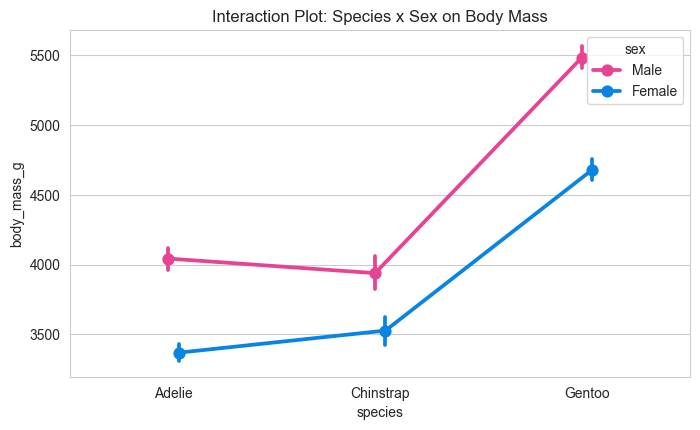

In [15]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.pointplot(data=penguins, x='species', y='body_mass_g', hue='sex',
              dodge=True, palette=['#e84393', '#0984e3'], ax=ax)
ax.set_title("Interaction Plot: Species x Sex on Body Mass")
plt.show()


**What to look for:** if the two lines (Male/Female) were perfectly parallel, there'd be no interaction. Here they're roughly parallel but not identical — worth discussing with students whether the gap looks meaningfully different across species, tying back to the interaction p-value above.


## 📋 Cheat Sheet — Stage 3 Recap

| Test | Compares | Groups | H₀ |
|---|---|---|---|
| **One-sample t-test** | Sample mean vs a fixed value | 1 | mean = claimed value |
| **Independent t-test** | Two separate groups | 2 (unrelated) | means are equal |
| **Paired t-test** | Same subjects, two time points/conditions | 2 (related) | mean difference = 0 |
| **One-way ANOVA** | 3+ separate groups | 3+ | all means equal |
| **Tukey HSD** | Every pair after significant ANOVA | 3+ | specific pair means equal |
| **Two-way ANOVA** | 2 factors + their interaction | 2+ per factor | main/interaction effects = 0 |

### Golden rule
Always confirm your Stage 2 assumptions (normality + equal variance) **before** trusting any of these results. If they fail, that's your cue to head to Stage 4 — the non-parametric alternatives (Mann-Whitney U, Kruskal-Wallis).

**Next up:** Stage 4 — when assumptions break, what do we do instead?
